# Exploratory Data Analysis - Five Number Summary

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import os

# Display full width for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [2]:
# Load the dataset
# Adjust the path if ALL_MERGED.csv is in a different location
df = pd.read_csv('../#0 Exploratory Data Analysis/ALL_MERGED.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

Dataset Shape: (3654, 15)

First few rows:
       Date  Nickel_Fut  Coal_Fut_Newcastle  Palm_Oil_Fut  USD_IDR  CNY_IDR  \
0  5/1/2015     13750.0                62.2          2136  12962.5  2089.78   
1  5/2/2015     13750.0                62.2          2136  12962.5  2089.78   
2  5/3/2015     13750.0                62.2          2136  12962.5  2089.78   
3  5/4/2015     13750.0                62.2          2136  12980.0  2090.51   
4  5/5/2015     14245.0                62.5          2136  13047.5  2102.39   

   EUR_IDR     BTC_USD      FTSE100     HANGSENG    NIKKEI225       SNP500  \
0  14519.9  232.078995  6986.000000  28123.82031  19531.63086  2108.290039   
1  14519.9  234.929993  6986.000000  28123.82031  19531.63086  2108.290039   
2  14519.9  240.358002  6986.000000  28123.82031  19531.63086  2108.290039   
3  14467.5  239.018005  6986.000000  28123.82031  19531.63086  2114.489990   
4  14594.9  236.121002  6927.600098  27755.53906  19531.63086  2089.459961   

         DOW3

In [3]:
# Generate Five Number Summary Table
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

five_number_summary = pd.DataFrame({
    'Min': numeric_df.min(),
    'Q1 (25%)': numeric_df.quantile(0.25),
    'Median (50%)': numeric_df.median(),
    'Q3 (75%)': numeric_df.quantile(0.75),
    'Max': numeric_df.max()
})

print("\n" + "="*100)
print("FIVE NUMBER SUMMARY")
print("="*100)
print(five_number_summary.round(4))
print("="*100)


FIVE NUMBER SUMMARY
                           Min    Q1 (25%)  Median (50%)    Q3 (75%)  \
Nickel_Fut           7590.0000  11567.5000    14850.0000  18314.8000   
Coal_Fut_Newcastle     48.5000     67.9000       98.3500    141.0750   
Palm_Oil_Fut         1759.0000   2387.0000     2932.5000   4010.2500   
USD_IDR             12947.5000  13665.0000    14310.0000  15020.0000   
CNY_IDR              1917.9500   2050.4400     2148.5750   2202.9500   
EUR_IDR             13922.7000  15324.9250    16193.2000  16896.8000   
BTC_USD               210.4950   3860.7916    10675.2104  37676.1338   
FTSE100              4993.8999   6837.3999     7298.3000   7565.7749   
HANGSENG            14687.0195  20278.8398    23957.2803  27160.2383   
NIKKEI225           14952.0195  20359.6992    23292.7305  28871.0620   
SNP500               1829.0800   2519.3601     3191.9850   4348.3301   
DOW30               15660.1797  22644.7173    27443.0703  34299.1211   
SSE_Composite        2464.3630   2978.8779 

In [4]:
# Export Five Number Summary to CSV
output_path = 'Five_Number_Summary.csv'
five_number_summary.to_csv(output_path)

print(f"\nFive Number Summary exported to: {output_path}")
print(f"File location: {os.path.abspath(output_path)}")


Five Number Summary exported to: Five_Number_Summary.csv
File location: c:\Users\Alden\Downloads\TESIS S2\Colab\#7 Significance Testing\Five_Number_Summary.csv


In [5]:
# Calculate Variance
variance = numeric_df.var()

print("\n" + "="*100)
print("VARIANCE")
print("="*100)
# Display with full decimal notation
pd.set_option('display.float_format', '{:.4f}'.format)
print(variance)
# Reset to default
pd.reset_option('display.float_format')
print("="*100)


VARIANCE
Nickel_Fut            34762403.0212
Coal_Fut_Newcastle        8357.9478
Palm_Oil_Fut           1311734.4046
USD_IDR                 842434.6163
CNY_IDR                   9669.8736
EUR_IDR                 969301.2535
BTC_USD              641961105.9992
FTSE100                 435045.4802
HANGSENG              16734678.9746
NIKKEI225             43330921.4507
SNP500                 1300830.5782
DOW30                 56758128.9805
SSE_Composite           104509.0921
JKSE                    711234.4486
dtype: float64


In [6]:
# Normality Tests: Shapiro-Wilk and Kolmogorov-Smirnov
from scipy import stats

# Set alpha level for significance
alpha = 0.05

# Create results dataframe
normality_results = pd.DataFrame(columns=['Shapiro-Wilk Statistic', 'Shapiro-Wilk p-value', 
                                           'Shapiro-Wilk Conclusion', 
                                           'KS Statistic', 'KS p-value', 
                                           'KS Conclusion'])

for column in numeric_df.columns:
    data = numeric_df[column].dropna()
    
    # Shapiro-Wilk Test
    sw_stat, sw_pvalue = stats.shapiro(data)
    sw_conclusion = "Reject H0 (Not Normal)" if sw_pvalue < alpha else "Accept H0 (Normal)"
    
    # Kolmogorov-Smirnov Test (against standard normal distribution)
    # Normalize the data first
    normalized_data = (data - data.mean()) / data.std()
    ks_stat, ks_pvalue = stats.kstest(normalized_data, 'norm')
    ks_conclusion = "Reject H0 (Not Normal)" if ks_pvalue < alpha else "Accept H0 (Normal)"
    
    normality_results.loc[column] = [sw_stat, sw_pvalue, sw_conclusion, 
                                      ks_stat, ks_pvalue, ks_conclusion]

print("\n" + "="*150)
print("NORMALITY TESTS (Alpha = 0.05)")
print("="*150)
print("\nShapiro-Wilk Test:")
print("-" * 150)
print(normality_results[['Shapiro-Wilk Statistic', 'Shapiro-Wilk p-value', 'Shapiro-Wilk Conclusion']].to_string())

print("\n\nKolmogorov-Smirnov Test:")
print("-" * 150)
print(normality_results[['KS Statistic', 'KS p-value', 'KS Conclusion']].to_string())

print("\n" + "="*150)
print("SUMMARY")
print("="*150)
print(f"Total Variables: {len(normality_results)}")
print(f"\nShapiro-Wilk - Normal Variables: {(normality_results['Shapiro-Wilk Conclusion'] == 'Accept H0 (Normal)').sum()}")
print(f"Shapiro-Wilk - Non-Normal Variables: {(normality_results['Shapiro-Wilk Conclusion'] == 'Reject H0 (Not Normal)').sum()}")
print(f"\nKS Test - Normal Variables: {(normality_results['KS Conclusion'] == 'Accept H0 (Normal)').sum()}")
print(f"KS Test - Non-Normal Variables: {(normality_results['KS Conclusion'] == 'Reject H0 (Not Normal)').sum()}")
print("="*150)


NORMALITY TESTS (Alpha = 0.05)

Shapiro-Wilk Test:
------------------------------------------------------------------------------------------------------------------------------------------------------
                    Shapiro-Wilk Statistic  Shapiro-Wilk p-value Shapiro-Wilk Conclusion
Nickel_Fut                        0.840684          2.248162e-51  Reject H0 (Not Normal)
Coal_Fut_Newcastle                0.719654          1.818374e-61  Reject H0 (Not Normal)
Palm_Oil_Fut                      0.905468          6.999980e-43  Reject H0 (Not Normal)
USD_IDR                           0.956309          8.879152e-32  Reject H0 (Not Normal)
CNY_IDR                           0.950265          1.605644e-33  Reject H0 (Not Normal)
EUR_IDR                           0.975320          1.119498e-24  Reject H0 (Not Normal)
BTC_USD                           0.829430          1.521968e-52  Reject H0 (Not Normal)
FTSE100                           0.975149          9.310802e-25  Reject H0 (Not Norm

In [7]:
# Export Normality Test Results to CSV
output_path = 'Normality_Tests_Results.csv'
normality_results.to_csv(output_path)

print(f"\nNormality test results exported to: {output_path}")
print(f"File location: {os.path.abspath(output_path)}")


Normality test results exported to: Normality_Tests_Results.csv
File location: c:\Users\Alden\Downloads\TESIS S2\Colab\#7 Significance Testing\Normality_Tests_Results.csv


In [8]:
# Augmented Dickey-Fuller Test
from statsmodels.tsa.stattools import adfuller

# Create results dataframe
adf_results = pd.DataFrame(columns=['ADF Statistic', 'p-value', 'Critical Value (5%)', 
                                     'Conclusion', 'Lags Used', 'Observations Used'])

for column in numeric_df.columns:
    data = numeric_df[column].dropna()
    
    # Perform ADF test
    result = adfuller(data, autolag='AIC')
    
    adf_stat = result[0]
    p_value = result[1]
    critical_value_5 = result[4]['5%']
    lags_used = result[2]
    nobs = result[3]
    
    # Conclusion: Reject H0 if p-value < 0.05 (series is stationary)
    conclusion = "Reject H0 (Stationary)" if p_value < alpha else "Accept H0 (Non-Stationary)"
    
    adf_results.loc[column] = [adf_stat, p_value, critical_value_5, conclusion, lags_used, nobs]

print("\n" + "="*150)
print("AUGMENTED DICKEY-FULLER TEST (Alpha = 0.05)")
print("="*150)
print("\nNull Hypothesis (H0): Series has a unit root (Non-Stationary)")
print("Alternative Hypothesis (H1): Series is Stationary")
print("-" * 150)
pd.set_option('display.float_format', '{:.6f}'.format)
print(adf_results.to_string())
pd.reset_option('display.float_format')
print("="*150)

# Export ADF Test Results to CSV
adf_output_path = 'ADF_Test_Results.csv'
adf_results.to_csv(adf_output_path)

print(f"\nADF test results exported to: {adf_output_path}")
print(f"File location: {os.path.abspath(adf_output_path)}")


AUGMENTED DICKEY-FULLER TEST (Alpha = 0.05)

Null Hypothesis (H0): Series has a unit root (Non-Stationary)
Alternative Hypothesis (H1): Series is Stationary
------------------------------------------------------------------------------------------------------------------------------------------------------
                    ADF Statistic  p-value  Critical Value (5%)                  Conclusion  Lags Used  Observations Used
Nickel_Fut              -2.316668 0.166649            -2.862338  Accept H0 (Non-Stationary)         30               3623
Coal_Fut_Newcastle      -1.657174 0.453302            -2.862337  Accept H0 (Non-Stationary)         27               3626
Palm_Oil_Fut            -1.859054 0.351561            -2.862335  Accept H0 (Non-Stationary)         18               3635
USD_IDR                 -1.640417 0.462043            -2.862333  Accept H0 (Non-Stationary)          6               3647
CNY_IDR                 -2.466792 0.123765            -2.862334  Accept H0 (Non-S

Correlation matrix heatmap saved as: Correlation_Matrix_Heatmap.png


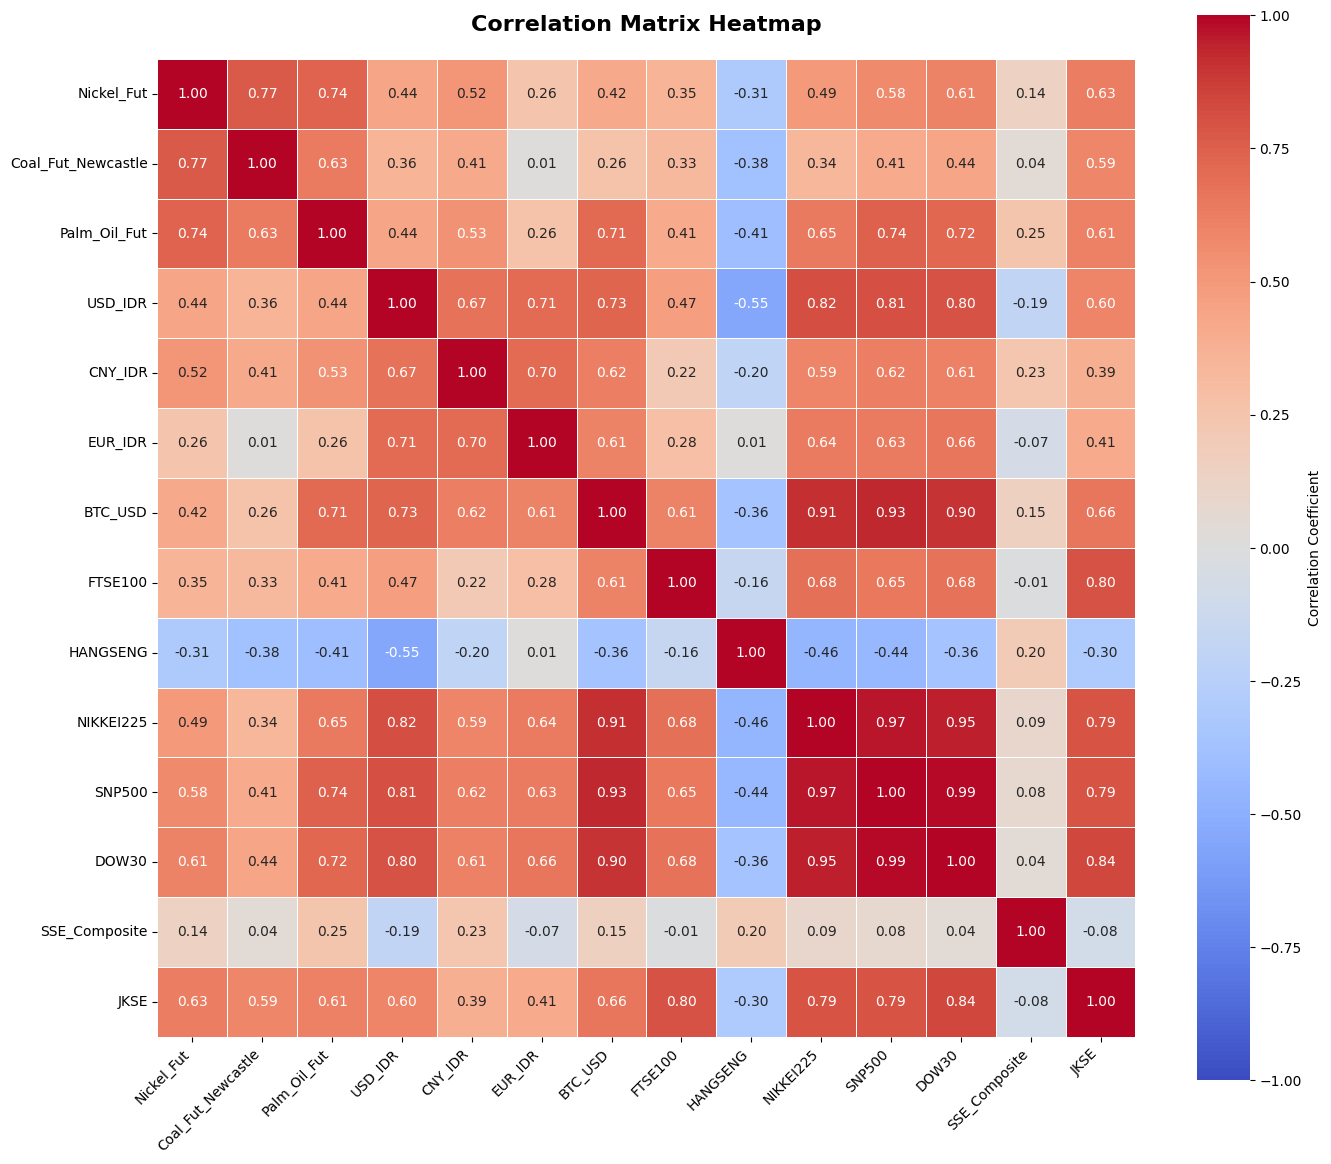


Correlation matrix exported to: Correlation_Matrix.csv
File location: c:\Users\Alden\Downloads\TESIS S2\Colab\#7 Significance Testing\Correlation_Matrix.csv


In [9]:
# Correlation Matrix Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

# Create figure and axes
plt.figure(figsize=(14, 12))

# Create heatmap
sns.heatmap(correlation_matrix, 
            annot=True,  # Show correlation values
            fmt='.2f',   # Format to 2 decimal places
            cmap='coolwarm',  # Color palette
            center=0,    # Center the colormap at 0
            square=True, # Make cells square
            linewidths=0.5,  # Add gridlines
            cbar_kws={'label': 'Correlation Coefficient'},
            vmin=-1, vmax=1)  # Set scale from -1 to 1

plt.title('Correlation Matrix Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save the figure
plt.savefig('Correlation_Matrix_Heatmap.png', dpi=300, bbox_inches='tight')
print("Correlation matrix heatmap saved as: Correlation_Matrix_Heatmap.png")

plt.show()

# Export correlation matrix to CSV
correlation_output_path = 'Correlation_Matrix.csv'
correlation_matrix.to_csv(correlation_output_path)
print(f"\nCorrelation matrix exported to: {correlation_output_path}")
print(f"File location: {os.path.abspath(correlation_output_path)}")

Running Granger Causality Tests... (this may take a moment)


c:\Users\Alden\.conda\envs\tesis_env\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\Alden\.conda\envs\tesis_env\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\Alden\.conda\envs\tesis_env\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\Alden\.conda\envs\tesis_env\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\Alden\.conda\envs\tesis_env\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\Alden\.conda\envs\tesis_env\Lib\site-packages\statsmodels\tsa\stat

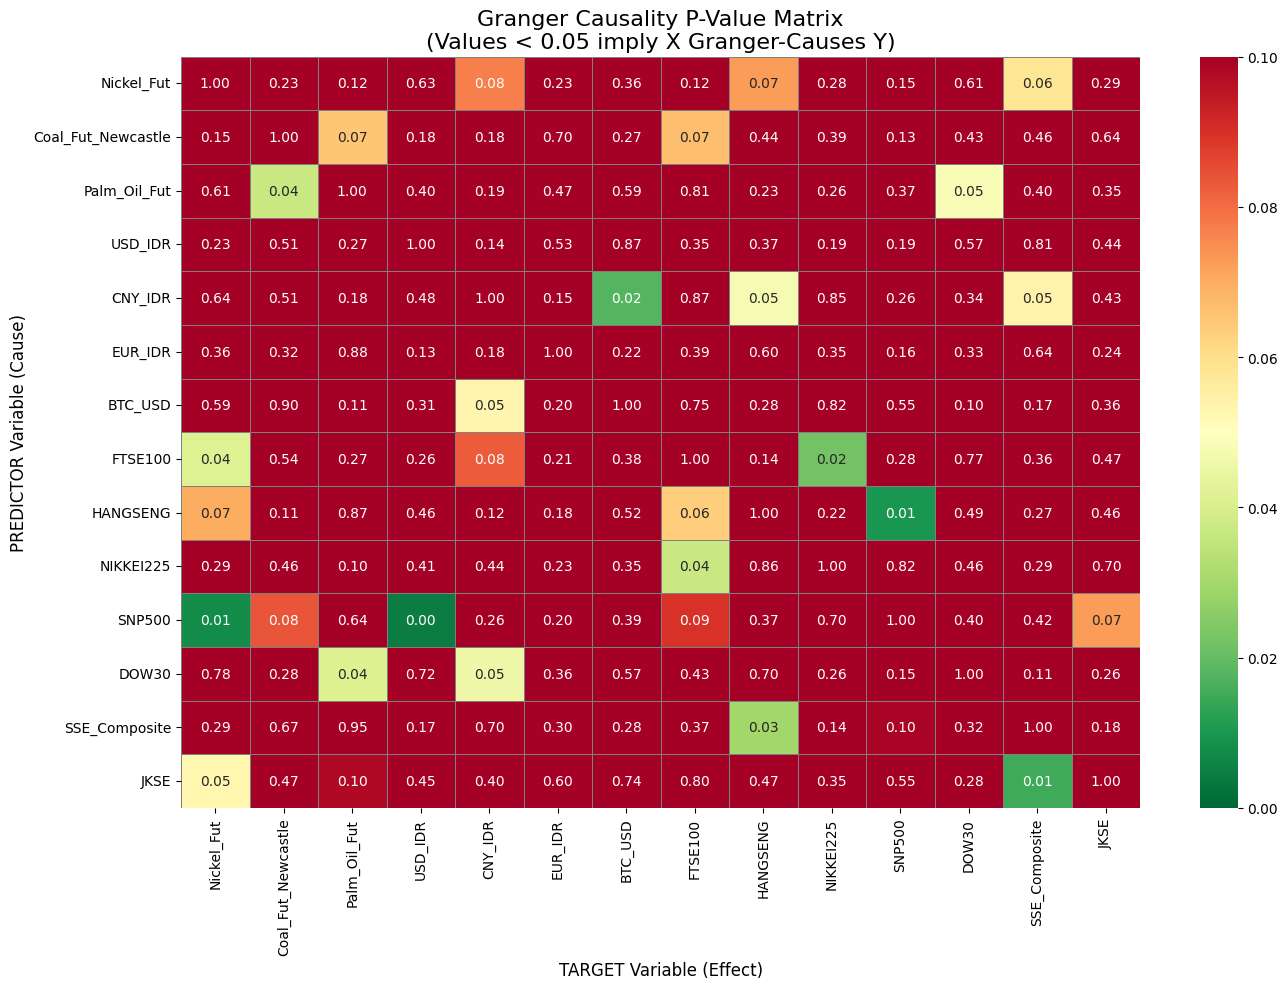

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import grangercausalitytests

# ---------------------------------------------------------
# 1. LOAD YOUR DATA
# Replace this block with: df = pd.read_csv('your_file.csv')
# Ensure 'Date' is parsed and set as index
# ---------------------------------------------------------
# Creating dummy data to simulate your dataset structure
np.random.seed(42)
dates = pd.date_range(start='2022-01-01', periods=300, freq='B')
columns = ['Nickel_Fut', 'Coal_Fut_Newcastle', 'Palm_Oil_Fut', 'USD_IDR', 
           'CNY_IDR', 'EUR_IDR', 'BTC_USD', 'FTSE100', 'HANGSENG', 
           'NIKKEI225', 'SNP500', 'DOW30', 'SSE_Composite', 'JKSE']
df = pd.DataFrame(np.cumsum(np.random.randn(300, len(columns)), axis=0), 
                  columns=columns, index=dates)

# ---------------------------------------------------------
# 2. PREPROCESSING (CRITICAL)
# ---------------------------------------------------------
# Granger Causality assumes STATIONARITY. Stock prices are rarely stationary.
# We must use "Returns" (Differencing) instead of raw prices.
df_processed = df.diff().dropna()

# ---------------------------------------------------------
# 3. CALCULATE GRANGER CAUSALITY MATRIX
# ---------------------------------------------------------
def granger_causality_matrix(data, variables, maxlag=5):
    """
    Calculates the p-value matrix for Granger Causality.
    Row = Predictor, Column = Target
    """
    matrix = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    
    for col in variables: # The Target (Y)
        for row in variables: # The Predictor (X)
            if col == row:
                matrix.loc[row, col] = 1.0 # Self-loop is ignored
                continue
            
            # Run test: check if X causes Y
            # We check multiple lags and take the BEST (min) p-value to be safe
            try:
                test_result = grangercausalitytests(data[[col, row]], maxlag=maxlag, verbose=False)
                # Extract p-values for the 'ssr_chi2test'
                p_values = [test_result[i+1][0]['ssr_chi2test'][1] for i in range(maxlag)]
                matrix.loc[row, col] = np.min(p_values)
            except:
                matrix.loc[row, col] = 1.0 # If test fails (e.g., constant data), assume no causality
                
    return matrix

# Run the calculation
print("Running Granger Causality Tests... (this may take a moment)")
p_value_matrix = granger_causality_matrix(df_processed, df_processed.columns, maxlag=3)

# ---------------------------------------------------------
# 4. VISUALIZATION
# ---------------------------------------------------------
plt.figure(figsize=(14, 10))

# Create Heatmap
# vmin=0, vmax=0.1 ensures we highlight significant values (typically < 0.05)
sns.heatmap(p_value_matrix, annot=True, cmap='RdYlGn_r', vmin=0, vmax=0.1, fmt='.2f',
            linewidths=0.5, linecolor='gray')

plt.title('Granger Causality P-Value Matrix\n(Values < 0.05 imply X Granger-Causes Y)', fontsize=16)
plt.xlabel('TARGET Variable (Effect)', fontsize=12)
plt.ylabel('PREDICTOR Variable (Cause)', fontsize=12)
plt.tight_layout()
plt.show()

Boxplot analysis saved as: Boxplot_Analysis.png


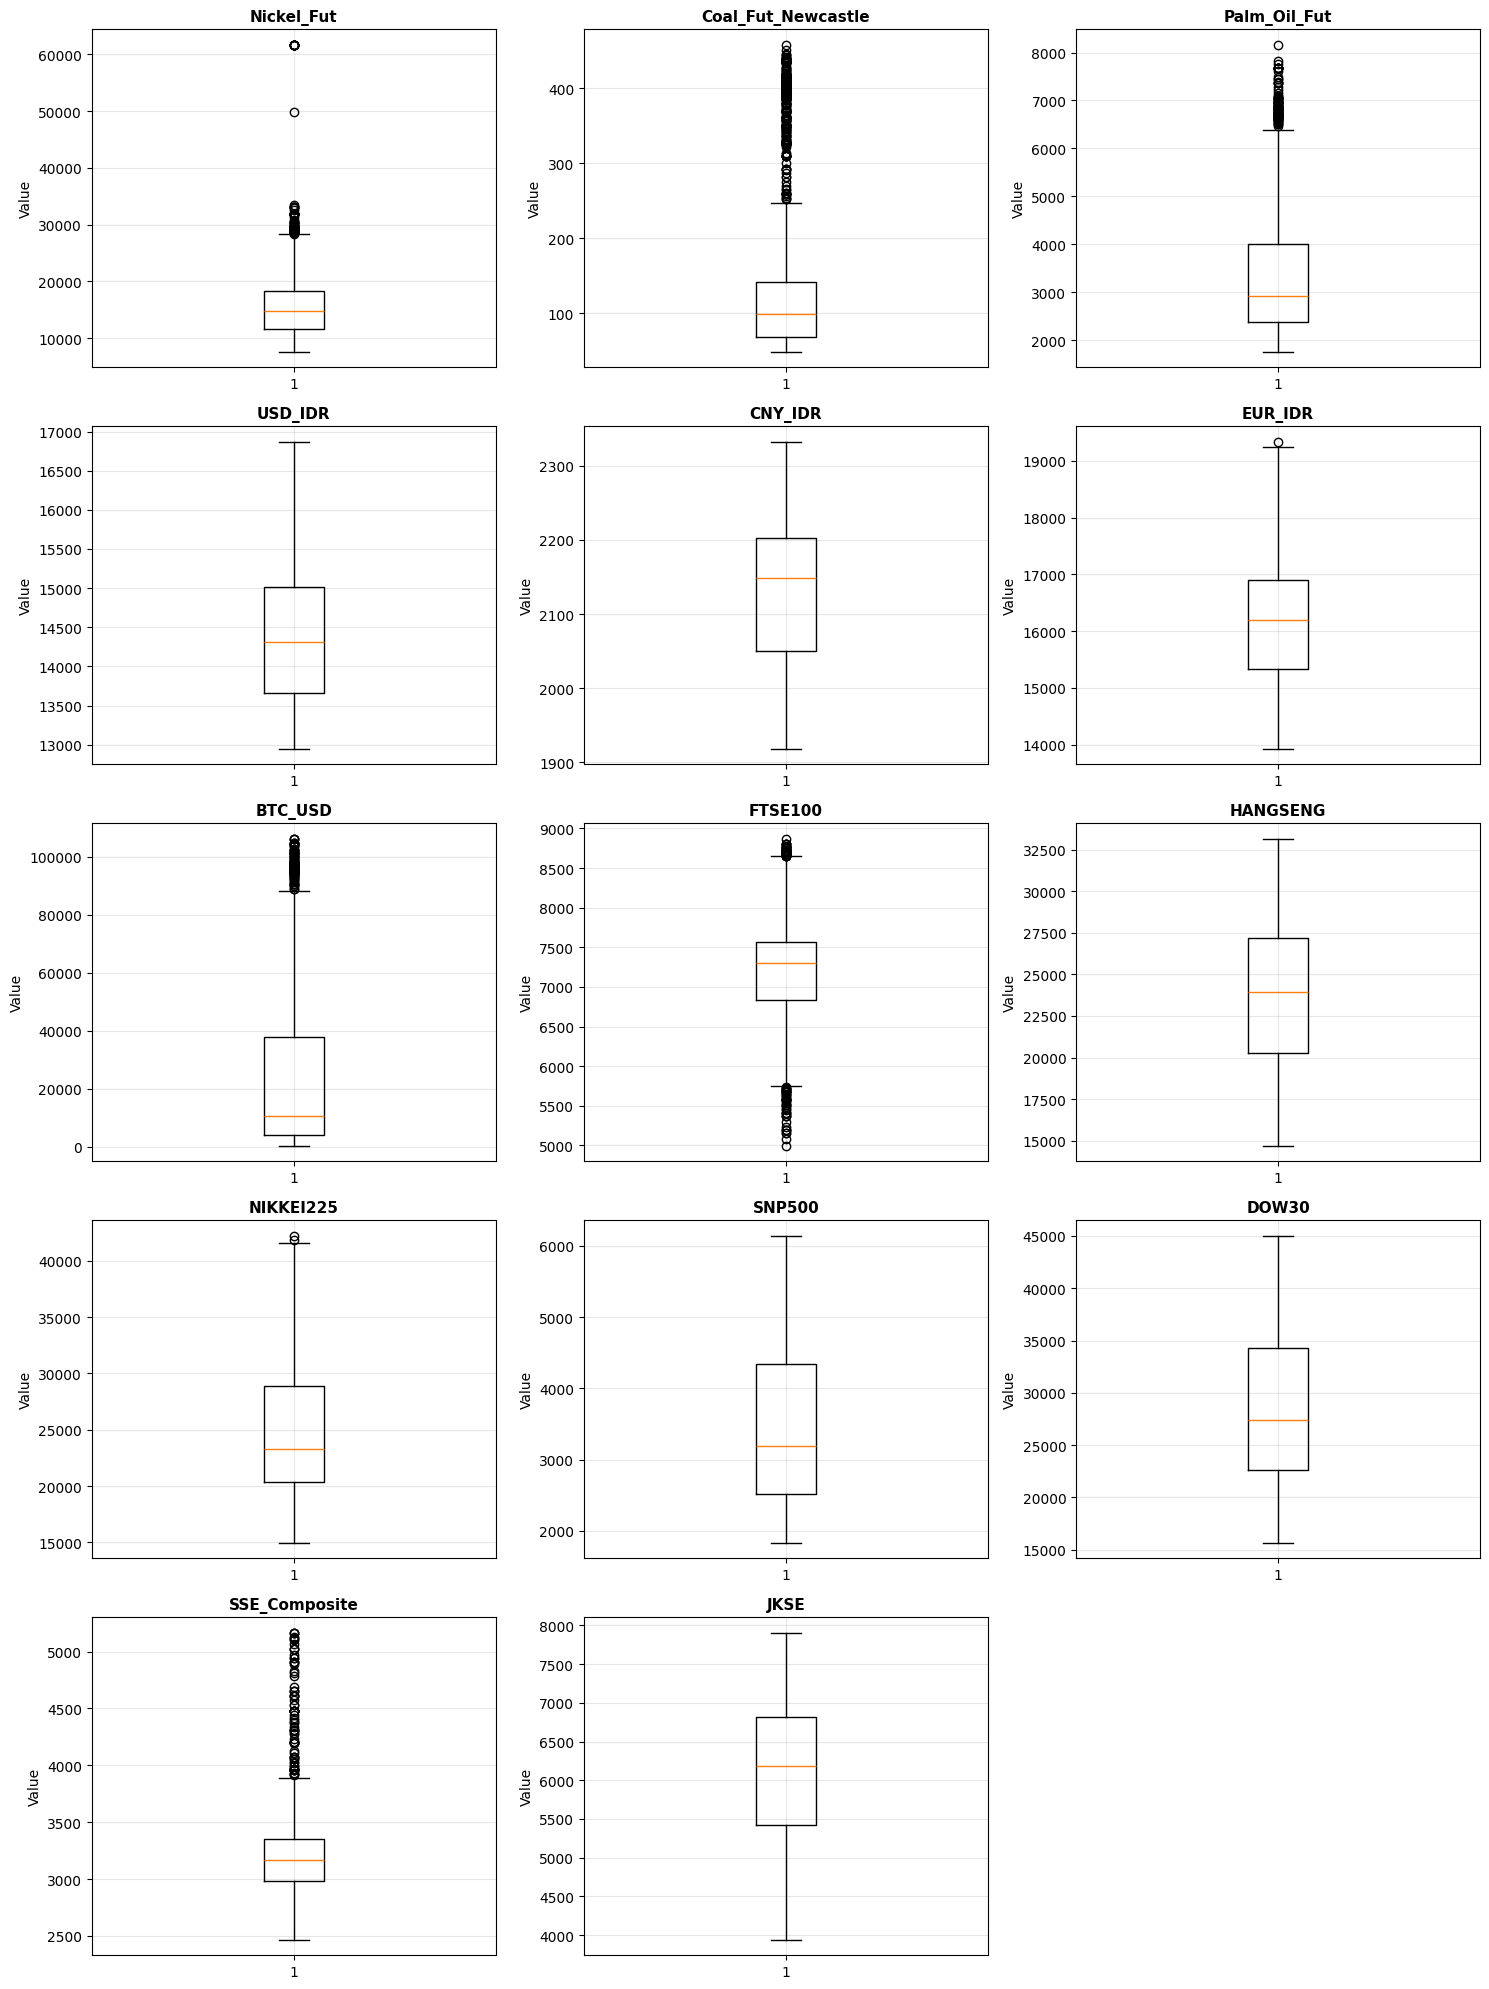

In [11]:
# Boxplot Analysis and Outlier Detection
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Create boxplots with 3 columns
numeric_columns = numeric_df.columns.tolist()
n_features = len(numeric_columns)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols  # Ceiling division for number of rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()  # Flatten to 1D for easier iteration

for idx, column in enumerate(numeric_columns):
    ax = axes[idx]
    ax.boxplot(numeric_df[column].dropna(), vert=True)
    ax.set_title(column, fontsize=11, fontweight='bold')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)

# Hide any unused subplots
for idx in range(n_features, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('Boxplot_Analysis.png', dpi=300, bbox_inches='tight')
print("Boxplot analysis saved as: Boxplot_Analysis.png")
plt.show()

In [12]:
# Outlier Detection and Summary Table
def detect_outliers_iqr(data):
    """Detect outliers using IQR method"""
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((data < lower_bound) | (data > upper_bound)).sum()
    return outliers

# Create summary table
outlier_summary = pd.DataFrame(columns=['Variable', 'Number of Outliers', 
                                        'Percentage of Outliers (%)', 'Distribution Type'])

for column in numeric_df.columns:
    data = numeric_df[column].dropna()
    n_total = len(data)
    n_outliers = detect_outliers_iqr(data)
    pct_outliers = (n_outliers / n_total) * 100
    
    # Determine distribution type from Shapiro-Wilk test
    if column in normality_results.index:
        dist_type = normality_results.loc[column, 'Shapiro-Wilk Conclusion']
        if dist_type == 'Accept H0 (Normal)':
            dist_type = 'Normal'
        else:
            dist_type = 'Non-Normal'
    else:
        dist_type = 'Unknown'
    
    outlier_summary = pd.concat([outlier_summary, pd.DataFrame({
        'Variable': [column],
        'Number of Outliers': [int(n_outliers)],
        'Percentage of Outliers (%)': [round(pct_outliers, 2)],
        'Distribution Type': [dist_type]
    })], ignore_index=True)

print("\n" + "="*100)
print("OUTLIER ANALYSIS SUMMARY")
print("="*100)
print(outlier_summary.to_string(index=False))
print("="*100)

# Export to CSV
outlier_output_path = 'Outlier_Analysis_Summary.csv'
outlier_summary.to_csv(outlier_output_path, index=False)
print(f"\nOutlier analysis summary exported to: {outlier_output_path}")
print(f"File location: {os.path.abspath(outlier_output_path)}")


OUTLIER ANALYSIS SUMMARY
          Variable Number of Outliers  Percentage of Outliers (%) Distribution Type
        Nickel_Fut                 99                        2.71        Non-Normal
Coal_Fut_Newcastle                341                        9.33        Non-Normal
      Palm_Oil_Fut                 98                        2.68        Non-Normal
           USD_IDR                  0                        0.00        Non-Normal
           CNY_IDR                  0                        0.00        Non-Normal
           EUR_IDR                  1                        0.03        Non-Normal
           BTC_USD                118                        3.23        Non-Normal
           FTSE100                 91                        2.49        Non-Normal
          HANGSENG                  0                        0.00        Non-Normal
         NIKKEI225                  2                        0.05        Non-Normal
            SNP500                  0             

C:\Users\Alden\AppData\Local\Temp\ipykernel_9316\4258092893.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  outlier_summary = pd.concat([outlier_summary, pd.DataFrame({


In [13]:
# Multicollinearity Test using VIF (Variance Inflation Factor)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each variable
# Remove any rows with missing values
numeric_df_clean = numeric_df.dropna()

vif_data = pd.DataFrame()
vif_data['Variable'] = numeric_df_clean.columns
vif_data['VIF'] = [variance_inflation_factor(numeric_df_clean.values, i) 
                    for i in range(numeric_df_clean.shape[1])]

# Sort by VIF in descending order
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

# Add interpretation column
def interpret_vif(vif_value):
    """Interpret VIF values"""
    if vif_value < 5:
        return 'Low Multicollinearity'
    elif vif_value < 10:
        return 'Moderate Multicollinearity'
    else:
        return 'High Multicollinearity'

vif_data['Multicollinearity Level'] = vif_data['VIF'].apply(interpret_vif)

print("\n" + "="*100)
print("MULTICOLLINEARITY TEST - VARIANCE INFLATION FACTOR (VIF)")
print("="*100)
print("\nVIF Interpretation:")
print("  VIF < 5: Low Multicollinearity (Acceptable)")
print("  VIF 5-10: Moderate Multicollinearity (Caution)")
print("  VIF > 10: High Multicollinearity (Issue)")
print("\n" + "-"*100)
print(vif_data.to_string(index=False))
print("-"*100)

# Summary statistics
print("\n" + "="*100)
print("VIF SUMMARY")
print("="*100)
print(f"Total Variables: {len(vif_data)}")
print(f"Variables with Low Multicollinearity (VIF < 5): {(vif_data['VIF'] < 5).sum()}")
print(f"Variables with Moderate Multicollinearity (VIF 5-10): {((vif_data['VIF'] >= 5) & (vif_data['VIF'] < 10)).sum()}")
print(f"Variables with High Multicollinearity (VIF >= 10): {(vif_data['VIF'] >= 10).sum()}")
print(f"\nMean VIF: {vif_data['VIF'].mean():.4f}")
print(f"Max VIF: {vif_data['VIF'].max():.4f}")
print(f"Min VIF: {vif_data['VIF'].min():.4f}")
print("="*100)

# Export to CSV
vif_output_path = 'VIF_Multicollinearity_Test.csv'
vif_data.to_csv(vif_output_path, index=False)
print(f"\nVIF results exported to: {vif_output_path}")
print(f"File location: {os.path.abspath(vif_output_path)}")


MULTICOLLINEARITY TEST - VARIANCE INFLATION FACTOR (VIF)

VIF Interpretation:
  VIF < 5: Low Multicollinearity (Acceptable)
  VIF 5-10: Moderate Multicollinearity (Caution)
  VIF > 10: High Multicollinearity (Issue)

----------------------------------------------------------------------------------------------------
          Variable         VIF Multicollinearity Level
             DOW30 2607.806625  High Multicollinearity
           CNY_IDR 2581.872622  High Multicollinearity
            SNP500 2175.473433  High Multicollinearity
           EUR_IDR 2171.656941  High Multicollinearity
           USD_IDR 1886.812529  High Multicollinearity
              JKSE  524.896814  High Multicollinearity
           FTSE100  487.369854  High Multicollinearity
         NIKKEI225  432.865405  High Multicollinearity
          HANGSENG  217.901146  High Multicollinearity
     SSE_Composite  213.595142  High Multicollinearity
      Palm_Oil_Fut   58.871187  High Multicollinearity
        Nickel_Fut   